## **iEEG Data** Exploration Notebook

#### Purpose: Inspect, extract, and visualize iEEG data from RCS and Percept devices


In [1]:
# =============================================================================
# CELL 1: Imports & Configuration
# =============================================================================
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Import your toolkit (same directory = no path needed)
import imat

# Override BASE_PATH in the notebook (more flexible than hardcoding in imat.py)
DATA_PATH = Path('/mnt/movement/users/jaizor/xtra/data/eeg/PD_Ecog')

# Optional: Enable autoreload (auto-updates imat.py if you edit it)
%load_ext autoreload
%autoreload 2

print("="*60)
print("PD_ECOG EXPLORATION NOTEBOOK")
print("="*60)
print("✓ Toolkit loaded")
print(f"✓ Data path: {DATA_PATH}")
print(f"✓ Autoreload enabled (edit imat.py → re-run to see changes)")
print("="*60)


PD_ECOG EXPLORATION NOTEBOOK
✓ Toolkit loaded
✓ Data path: /mnt/movement/users/jaizor/xtra/data/eeg/PD_Ecog
✓ Autoreload enabled (edit imat.py → re-run to see changes)


In [2]:
# =============================================================================
# CELL 2: Inspect RCS File Structure (First-Time Only)
# =============================================================================
# We validated Percept (sbj11). Now stress-test on RCS (sbj1).
# Run this ONCE per new file type to understand the structure.

rcs_file = DATA_PATH / 'sbj1_PM1_RCS' / 'RCS_DBSOFF_bima.mat'

print(f"\n🔍 Inspecting: {rcs_file.name}")
print(f"   Path: {rcs_file.parent}")
imat.inspect_mat_file(rcs_file, max_depth=2)



🔍 Inspecting: RCS_DBSOFF_bima.mat
   Path: /mnt/movement/users/jaizor/xtra/data/eeg/PD_Ecog/sbj1_PM1_RCS

FILE: RCS_DBSOFF_bima.mat
Size: 18761.3 KB

📦 Top-level keys (1):
  • SDATA → STRUCT (7 fields)

🔍 Deep dive: [SDATA]
----------------------------------------------------------------------
  ├─ info: <struct (3 fields)>
  ├─ rcs_dbs_left: (221585,), NaNs=149
  ├─ rcs_ecog_8_9_left: (221585,), NaNs=149
  ├─ rcs_ecog_10_11_left: (221585,), NaNs=149
  ├─ rcs_dbs_right: (221601,), NaNs=1475
  ├─ rcs_ecog_8_9_right: (221601,), NaNs=1475
  ├─ rcs_ecog_10_11_right: (221601,), NaNs=1475


{'__header__': b'MATLAB 5.0 MAT-file, Platform: MACI64, Created on: Wed Jan 29 16:03:57 2025',
 '__version__': '1.0',
 '__globals__': [],
 'SDATA': <scipy.io.matlab._mio5_params.mat_struct at 0x7f6de4184050>,
 '__function_workspace__': array([[ 0,  1, 73, ...,  0,  0,  0]], shape=(1, 31817032), dtype=uint8)}

In [3]:
# =============================================================================
# CELL 3: Extract RCS Data
# =============================================================================
# Extract all available channels from the RCS file.

print(f"\n📦 Extracting data from: {rcs_file.name}")
rcs_data = imat.extract_rcs_data(rcs_file, detrend=False)

if rcs_data['channels']:
    print(f"\n✓ Extraction successful!")
    print(f"  • Channels: {len(rcs_data['channels'])}")
    print(f"  • Sampling rate: {rcs_data['sfreq']} Hz")
    print(f"  • Channel names: {list(rcs_data['channels'].keys())}")
else:
    print("❌ No channels extracted—check inspect output above")


📦 Extracting data from: RCS_DBSOFF_bima.mat
⚠️ Length mismatch detected. Truncating to 221585 samples.

✓ Extraction successful!
  • Channels: 6
  • Sampling rate: 250.0 Hz
  • Channel names: ['STN-L', 'STN-R', 'ECOG-8-9-L', 'ECOG-10-11-L', 'ECOG-8-9-R', 'ECOG-10-11-R']


In [4]:
# =============================================================================
# CELL 4: Debug - Check Data Quality (Optional but Recommended)
# =============================================================================
# Inspect extracted data for NaNs, amplitude ranges, and potential issues.
# This helps catch problems BEFORE plotting.

print("\n" + "="*60)
print("DATA QUALITY CHECK")
print("="*60)

ch_names = list(rcs_data['channels'].keys())

for ch_name in ch_names:
    ch_data = rcs_data['channels'][ch_name]
    nan_count = np.isnan(ch_data).sum()
    nan_pct = 100 * nan_count / len(ch_data)
    
    print(f"\n{ch_name}:")
    print(f"  Shape: {ch_data.shape}")
    print(f"  Duration: {len(ch_data)/rcs_data['sfreq']:.1f}s")
    print(f"  Min: {np.nanmin(ch_data):.4f} μV")
    print(f"  Max: {np.nanmax(ch_data):.4f} μV")
    print(f"  Mean: {np.nanmean(ch_data):.4f} μV")
    print(f"  Std: {np.nanstd(ch_data):.4f} μV")
    print(f"  NaNs: {nan_count} ({nan_pct:.2f}%)")
    
    # Flag potential issues
    if nan_pct > 1.0:
        print(f"  ⚠️ WARNING: High NaN percentage (>1%)")
    if abs(np.nanmean(ch_data)) > 10:
        print(f"  ⚠️ WARNING: Large DC offset (consider detrending)")


DATA QUALITY CHECK

STN-L:
  Shape: (221585,)
  Duration: 886.3s
  Min: -2.4469 μV
  Max: 2.3329 μV
  Mean: -0.0682 μV
  Std: 0.0749 μV
  NaNs: 149 (0.07%)

STN-R:
  Shape: (221585,)
  Duration: 886.3s
  Min: -2.5159 μV
  Max: 2.2156 μV
  Mean: -0.1597 μV
  Std: 0.0677 μV
  NaNs: 1475 (0.67%)

ECOG-8-9-L:
  Shape: (221585,)
  Duration: 886.3s
  Min: -0.3630 μV
  Max: 0.0563 μV
  Mean: -0.1162 μV
  Std: 0.0214 μV
  NaNs: 149 (0.07%)

ECOG-10-11-L:
  Shape: (221585,)
  Duration: 886.3s
  Min: -0.3216 μV
  Max: 0.0389 μV
  Mean: -0.1148 μV
  Std: 0.0202 μV
  NaNs: 149 (0.07%)

ECOG-8-9-R:
  Shape: (221585,)
  Duration: 886.3s
  Min: -0.4145 μV
  Max: -0.1446 μV
  Mean: -0.2071 μV
  Std: 0.0130 μV
  NaNs: 1475 (0.67%)

ECOG-10-11-R:
  Shape: (221585,)
  Duration: 886.3s
  Min: -0.2803 μV
  Max: -0.0210 μV
  Mean: -0.1402 μV
  Std: 0.0148 μV
  NaNs: 1475 (0.67%)


In [5]:
# =============================================================================
# CELL 5: Stack Channels for Visualization
# =============================================================================
# Stack all channels into a single array for plotting.
# Handles length mismatches automatically (already done in extract_rcs_data).

data_stack = np.vstack([rcs_data['channels'][ch] for ch in ch_names])

print(f"\n✓ Stacked data shape: {data_stack.shape} (channels × samples)")
print(f"  • {data_stack.shape[0]} channels")
print(f"  • {data_stack.shape[1]} samples")
print(f"  • {data_stack.shape[1]/rcs_data['sfreq']:.1f} seconds")


✓ Stacked data shape: (6, 221585) (channels × samples)
  • 6 channels
  • 221585 samples
  • 886.3 seconds


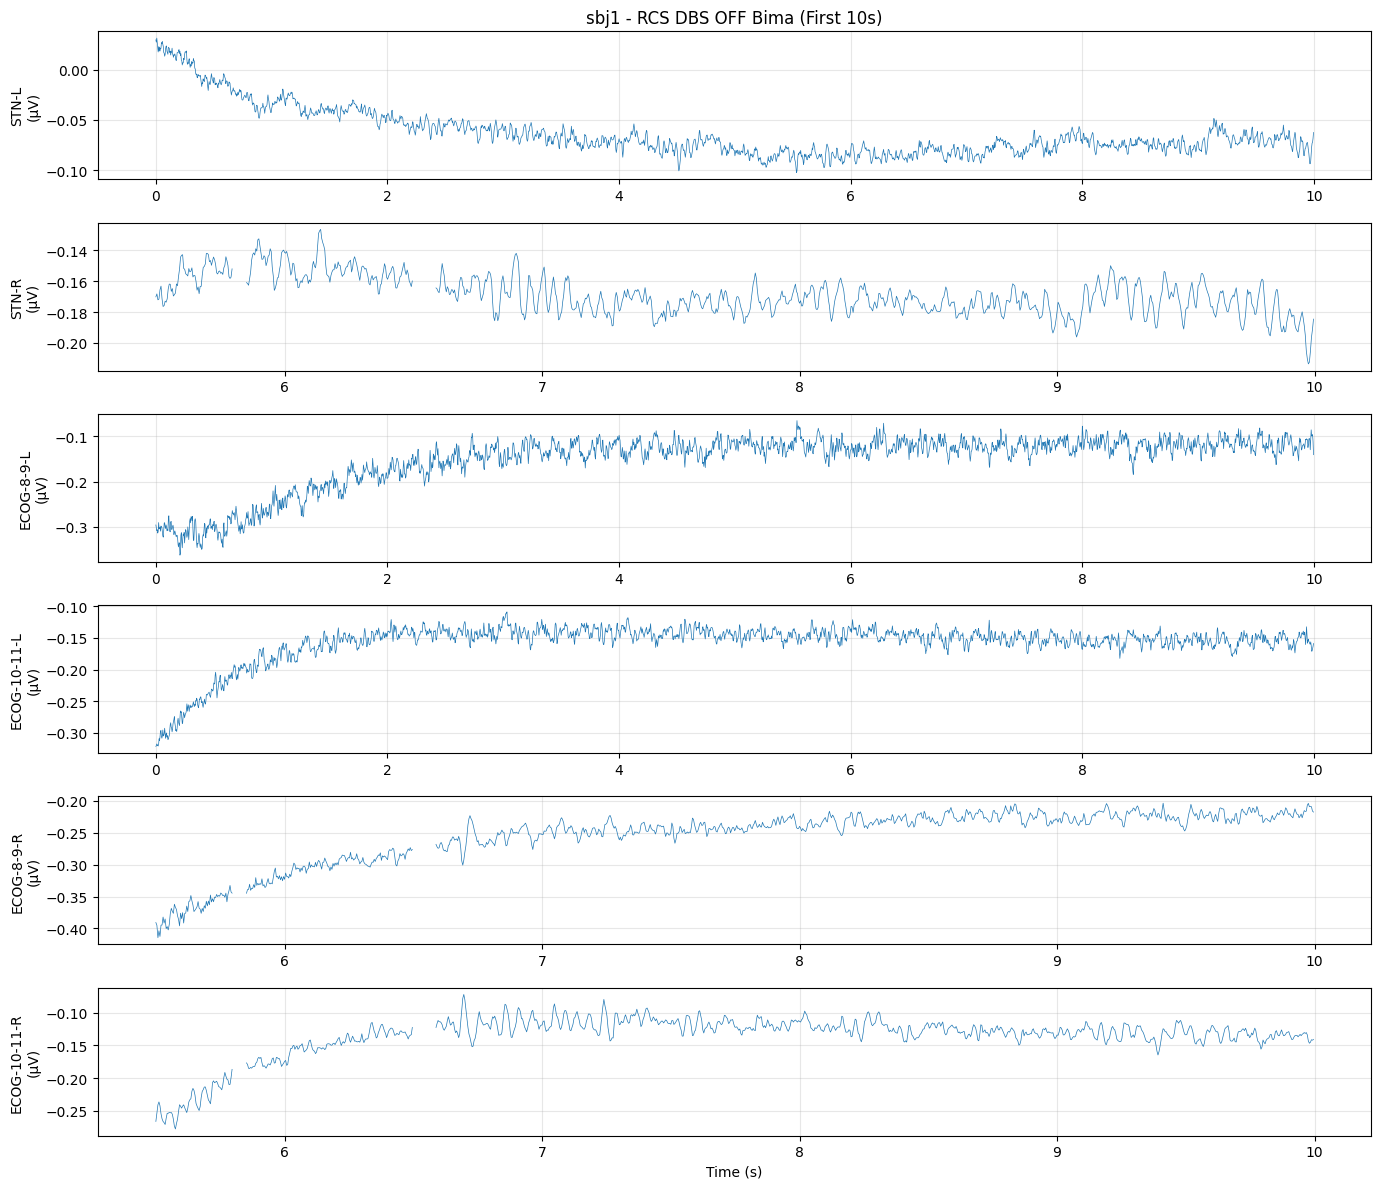

In [6]:
# =============================================================================
# CELL 6: Plot Raw Trace (First 10 Seconds)
# =============================================================================
# Visual inspection of signal quality, artifacts, and oscillations.

imat.plot_raw_trace(
    data_stack, 
    rcs_data['sfreq'], 
    title='sbj1 - RCS DBS OFF Bima', 
    duration=10,  # Show first 10 seconds
    ch_names=ch_names
)

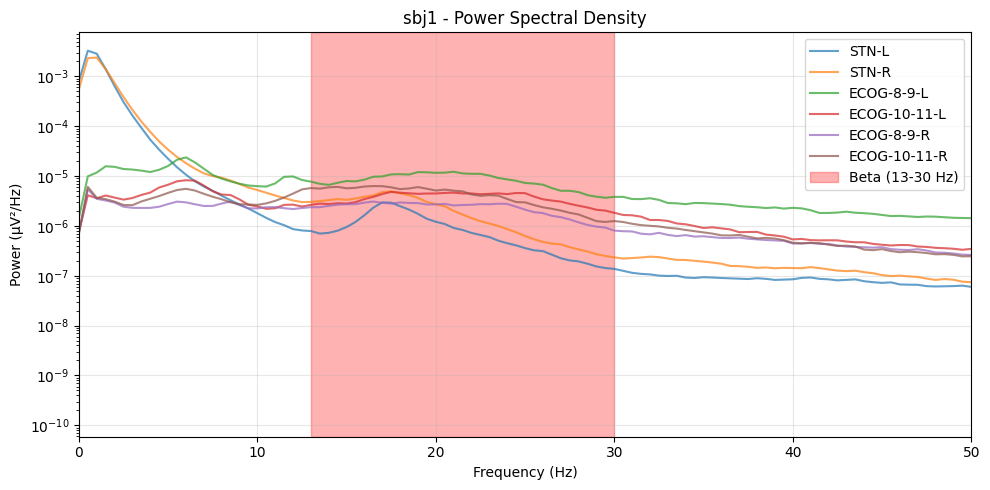

In [7]:
# =============================================================================
# CELL 7: Plot Power Spectral Density (PSD)
# =============================================================================
# Frequency-domain visualization. Look for:
#   • Beta elevation (13-30 Hz) in STN → PD biomarker
#   • 1/f slope → normal neural background
#   • 50/60 Hz peak → line noise artifact

imat.plot_psd(
    data_stack, 
    rcs_data['sfreq'], 
    title='sbj1 - Power Spectral Density', 
    ch_names=ch_names,
    fmax=50,  # Display up to 50 Hz
    interpolate_nans=True  # 🔧 Critical: handles NaNs in RCS data
)


🔍 Comparing STN vs ECoG...
  STN channels: ['STN-L', 'STN-R']
  ECoG channels: ['ECOG-8-9-L', 'ECOG-10-11-L', 'ECOG-8-9-R', 'ECOG-10-11-R']


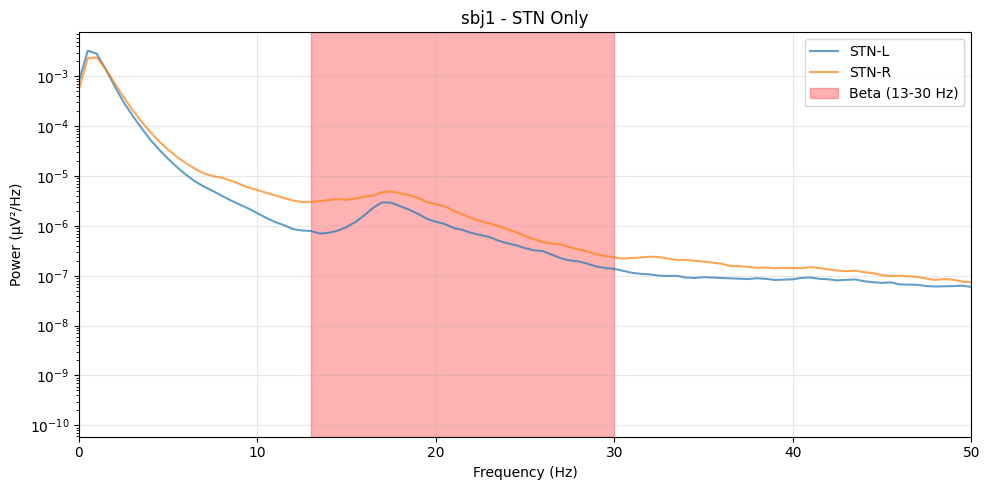

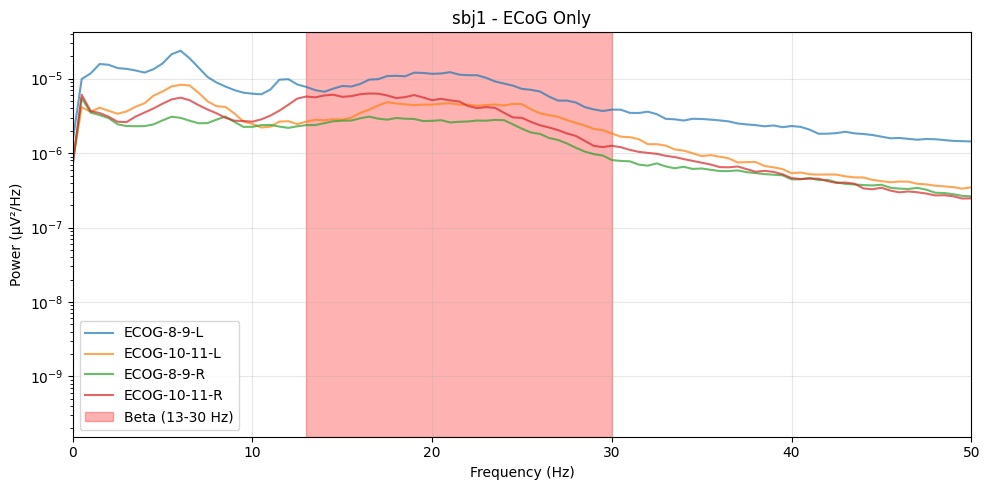

In [8]:
# =============================================================================
# CELL 8: Compare STN vs ECoG (RCS-Specific Analysis)
# =============================================================================
# RCS has both deep (STN) and cortical (ECoG) recordings.
# Compare their spectral profiles to understand cortico-subcortical dynamics.

stn_channels = [ch for ch in ch_names if 'STN' in ch]
ecog_channels = [ch for ch in ch_names if 'ECOG' in ch]

if stn_channels and ecog_channels:
    print(f"\n🔍 Comparing STN vs ECoG...")
    print(f"  STN channels: {stn_channels}")
    print(f"  ECoG channels: {ecog_channels}")
    
    # Plot STN only
    stn_data = np.vstack([rcs_data['channels'][ch] for ch in stn_channels])
    imat.plot_psd(stn_data, rcs_data['sfreq'], 
                 title='sbj1 - STN Only', 
                 ch_names=stn_channels,
                 fmax=50)
    
    # Plot ECoG only
    ecog_data = np.vstack([rcs_data['channels'][ch] for ch in ecog_channels])
    imat.plot_psd(ecog_data, rcs_data['sfreq'], 
                 title='sbj1 - ECoG Only', 
                 ch_names=ecog_channels,
                 fmax=50)
else:
    print("\n⚠️ Cannot compare: missing STN or ECoG channels")


In [9]:
# =============================================================================
# CELL 9: Compute Quality Metrics
# =============================================================================
# Generate quantitative metrics for this recording.
# Useful for batch processing and outlier detection.

metrics = imat.compute_quality_metrics(data_stack, rcs_data['sfreq'])

print("\n" + "="*60)
print("QUALITY METRICS SUMMARY")
print("="*60)

for ch_name, m in metrics.items():
    print(f"\n{ch_names[int(ch_name[2:])]}:")
    print(f"  Duration: {m['duration_sec']:.1f}s")
    print(f"  NaN %: {m['nan_pct']:.2f}%")
    print(f"  Std: {m['std_uv']:.4f} μV")
    print(f"  Beta power (13-30 Hz): {m['beta_power']:.6e} μV²/Hz")
    print(f"  Theta power (4-8 Hz): {m['theta_power']:.6e} μV²/Hz")
    print(f"  Beta/Theta ratio: {m['beta_theta_ratio']:.2f}")



# imat.example_rcs_extraction()




QUALITY METRICS SUMMARY

STN-L:
  Duration: 886.3s
  NaN %: 0.07%
  Std: 0.0749 μV
  Beta power (13-30 Hz): 9.346758e-07 μV²/Hz
  Theta power (4-8 Hz): 1.764332e-05 μV²/Hz
  Beta/Theta ratio: 0.05

STN-R:
  Duration: 886.3s
  NaN %: 0.67%
  Std: 0.0677 μV
  Beta power (13-30 Hz): 2.070976e-06 μV²/Hz
  Theta power (4-8 Hz): 2.751251e-05 μV²/Hz
  Beta/Theta ratio: 0.08

ECOG-8-9-L:
  Duration: 886.3s
  NaN %: 0.07%
  Std: 0.0214 μV
  Beta power (13-30 Hz): 8.337176e-06 μV²/Hz
  Theta power (4-8 Hz): 1.543779e-05 μV²/Hz
  Beta/Theta ratio: 0.54

ECOG-10-11-L:
  Duration: 886.3s
  NaN %: 0.07%
  Std: 0.0202 μV
  Beta power (13-30 Hz): 3.661847e-06 μV²/Hz
  Theta power (4-8 Hz): 6.366891e-06 μV²/Hz
  Beta/Theta ratio: 0.58

ECOG-8-9-R:
  Duration: 886.3s
  NaN %: 0.67%
  Std: 0.0130 μV
  Beta power (13-30 Hz): 2.303514e-06 μV²/Hz
  Theta power (4-8 Hz): 2.681568e-06 μV²/Hz
  Beta/Theta ratio: 0.86

ECOG-10-11-R:
  Duration: 886.3s
  NaN %: 0.67%
  Std: 0.0148 μV
  Beta power (13-30 Hz): 4.